In [1]:
# ============================================================
# Standalone Galerkin Neural Operator Quantitative Evaluation
#
# PT -> PA
#
# Metrics calculated on DENORMALIZED PA:
#
#   MSE      ↓
#   MAE      ↓
#   RMSE     ↓
#   Rel. L2  ↓
#   R²       ↑
#
# ============================================================

import os
import glob
import csv
import random
import time

import numpy as np
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


# ============================================================
# 1. Configuration
# ============================================================

DATA_ROOT = r"Training dataset"


# ------------------------------------------------------------
# CHANGE THIS
#
# Example:
#
# RUN_DIR =
# r"galerkin_operator_results/run_20260827_105515"
# ------------------------------------------------------------

RUN_DIR = r"galerkin_operator_results/run_20260821_143906"


MODEL_PATH = os.path.join(
    RUN_DIR,
    "best_galerkin_operator.pt"
)

NORM_PATH = os.path.join(
    RUN_DIR,
    "normalization_parameters.npz"
)

SUMMARY_PATH = os.path.join(
    RUN_DIR,
    "quantitative_metrics.txt"
)

CSV_PATH = os.path.join(
    RUN_DIR,
    "per_sample_metrics.csv"
)


# ============================================================
# 2. Dataset configuration
# ============================================================

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

SEED = 42

NT = 501
NX = 200


# ============================================================
# 3. Galerkin Operator parameters
#
# MUST match original training
# ============================================================

IN_CHANNELS = 1
OUT_CHANNELS = 1

PATCH_T = 4
PATCH_X = 4

D_MODEL = 96

N_HEADS = 4

N_LAYERS = 4

MLP_RATIO = 2

DROPOUT = 0.0


# ============================================================
# Evaluation batch size
# ============================================================

BATCH_SIZE = 4


# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 76)
print("GALERKIN NEURAL OPERATOR QUANTITATIVE EVALUATION")
print("=" * 76)

print("\nUsing device:", DEVICE)


# ============================================================
# 4. Check files
# ============================================================

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        f"\nCannot find model:\n"
        f"{MODEL_PATH}\n\n"
        f"Please modify RUN_DIR."
    )


if not os.path.exists(NORM_PATH):

    raise FileNotFoundError(
        f"\nCannot find normalization file:\n"
        f"{NORM_PATH}"
    )


print("\nModel:")
print(MODEL_PATH)

print("\nNormalization:")
print(NORM_PATH)


# ============================================================
# 5. Random seed
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 6. Find all MAT files
# ============================================================

all_files = glob.glob(

    os.path.join(
        DATA_ROOT,
        "**",
        "*.mat"
    ),

    recursive=True
)


all_files = sorted(all_files)


print(
    "\nTotal .mat samples found:",
    len(all_files)
)


if len(all_files) == 0:

    raise RuntimeError(
        f"No MAT files found under:\n"
        f"{DATA_ROOT}"
    )


# ============================================================
# 7. Reproduce original split
# ============================================================

random.shuffle(all_files)


n_total = len(all_files)

n_train = int(
    n_total * TRAIN_RATIO
)

n_val = int(
    n_total * VAL_RATIO
)


train_files = all_files[
    :n_train
]

val_files = all_files[
    n_train:
    n_train + n_val
]

test_files = all_files[
    n_train + n_val:
]


print("\nDataset split:")

print(
    "Train:",
    len(train_files)
)

print(
    "Val  :",
    len(val_files)
)

print(
    "Test :",
    len(test_files)
)


# ============================================================
# 8. Load original normalization parameters
# ============================================================

norm = np.load(
    NORM_PATH
)


pt_mean = float(
    norm["pt_mean"]
)

pt_std = float(
    norm["pt_std"]
)

pa_mean = float(
    norm["pa_mean"]
)

pa_std = float(
    norm["pa_std"]
)


print("\nNormalization parameters:")

print(
    f"PT mean = {pt_mean:.8e}"
)

print(
    f"PT std  = {pt_std:.8e}"
)

print(
    f"PA mean = {pa_mean:.8e}"
)

print(
    f"PA std  = {pa_std:.8e}"
)


# ============================================================
# 9. Dataset
# ============================================================

class MatHeatAcousticDataset(Dataset):

    def __init__(
        self,
        file_list,
        pt_mean,
        pt_std,
        pa_mean,
        pa_std
    ):

        self.file_list = file_list

        self.pt_mean = pt_mean
        self.pt_std = pt_std

        self.pa_mean = pa_mean
        self.pa_std = pa_std


    def __len__(self):

        return len(
            self.file_list
        )


    def __getitem__(
        self,
        idx
    ):

        mat_path = self.file_list[
            idx
        ]


        with h5py.File(
            mat_path,
            "r"
        ) as f:

            PT = np.asarray(
                f["PT"],
                dtype=np.float32
            )

            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )


        if PT.shape != (
            NT,
            NX
        ):

            raise ValueError(
                f"Wrong PT shape in:\n"
                f"{mat_path}\n"
                f"{PT.shape}"
            )


        if PA.shape != (
            NT,
            NX
        ):

            raise ValueError(
                f"Wrong PA shape in:\n"
                f"{mat_path}\n"
                f"{PA.shape}"
            )


        # ====================================================
        # Normalize
        # ====================================================

        PT = (
            PT
            -
            self.pt_mean
        ) / self.pt_std


        PA = (
            PA
            -
            self.pa_mean
        ) / self.pa_std


        # [T,X] -> [C,T,X]

        PT = torch.tensor(
            PT,
            dtype=torch.float32
        ).unsqueeze(0)


        PA = torch.tensor(
            PA,
            dtype=torch.float32
        ).unsqueeze(0)


        return (
            PT,
            PA,
            mat_path
        )


# ============================================================
# 10. Test loader
# ============================================================

test_dataset = MatHeatAcousticDataset(

    test_files,

    pt_mean,
    pt_std,

    pa_mean,
    pa_std
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


print(
    "\nTest loader ready."
)


# ============================================================
# 11. Patch Embedding
# ============================================================

class PatchEmbedding(nn.Module):

    def __init__(
        self,
        in_channels,
        embed_dim,
        patch_t,
        patch_x
    ):

        super().__init__()


        self.projection = nn.Conv2d(

            in_channels,

            embed_dim,

            kernel_size=(
                patch_t,
                patch_x
            ),

            stride=(
                patch_t,
                patch_x
            )
        )


    def forward(
        self,
        x
    ):

        return self.projection(
            x
        )


# ============================================================
# 12. Coordinate Embedding
# ============================================================

class CoordinateEmbedding(nn.Module):

    def __init__(
        self,
        embed_dim
    ):

        super().__init__()


        self.net = nn.Sequential(

            nn.Linear(
                2,
                embed_dim
            ),

            nn.GELU(),

            nn.Linear(
                embed_dim,
                embed_dim
            )
        )


    def forward(
        self,
        batch_size,
        height,
        width,
        device
    ):


        t = torch.linspace(

            -1.0,

            1.0,

            height,

            device=device
        )


        x = torch.linspace(

            -1.0,

            1.0,

            width,

            device=device
        )


        tt, xx = torch.meshgrid(

            t,

            x,

            indexing="ij"
        )


        coords = torch.stack(

            [
                tt,
                xx
            ],

            dim=-1
        )


        coords = coords.reshape(
            -1,
            2
        )


        coords = self.net(
            coords
        )


        coords = coords.unsqueeze(
            0
        )


        coords = coords.expand(

            batch_size,

            -1,

            -1
        )


        return coords


# ============================================================
# 13. Galerkin Attention
#
# Y = Q (K^T V / N)
# ============================================================

class GalerkinAttention(nn.Module):

    def __init__(
        self,
        dim,
        num_heads
    ):

        super().__init__()


        assert (
            dim % num_heads == 0
        )


        self.dim = dim

        self.num_heads = (
            num_heads
        )

        self.head_dim = (
            dim
            //
            num_heads
        )


        self.q_proj = nn.Linear(
            dim,
            dim,
            bias=False
        )


        self.k_proj = nn.Linear(
            dim,
            dim,
            bias=False
        )


        self.v_proj = nn.Linear(
            dim,
            dim,
            bias=False
        )


        self.out_proj = nn.Linear(
            dim,
            dim
        )


        self.q_norm = nn.LayerNorm(
            self.head_dim
        )


        self.k_norm = nn.LayerNorm(
            self.head_dim
        )


        self.v_norm = nn.LayerNorm(
            self.head_dim
        )


    def forward(
        self,
        x
    ):


        B, N, C = x.shape


        q = self.q_proj(
            x
        )

        k = self.k_proj(
            x
        )

        v = self.v_proj(
            x
        )


        q = q.reshape(

            B,
            N,
            self.num_heads,
            self.head_dim
        )


        k = k.reshape(

            B,
            N,
            self.num_heads,
            self.head_dim
        )


        v = v.reshape(

            B,
            N,
            self.num_heads,
            self.head_dim
        )


        q = self.q_norm(
            q
        )

        k = self.k_norm(
            k
        )

        v = self.v_norm(
            v
        )


        q = q.permute(
            0,
            2,
            1,
            3
        )


        k = k.permute(
            0,
            2,
            1,
            3
        )


        v = v.permute(
            0,
            2,
            1,
            3
        )


        # ====================================================
        # K^T V
        # ====================================================

        kv = torch.einsum(

            "bhnd,bhne->bhde",

            k,

            v
        )


        kv = (
            kv
            /
            float(N)
        )


        # ====================================================
        # Q (K^T V)
        # ====================================================

        out = torch.einsum(

            "bhnd,bhde->bhne",

            q,

            kv
        )


        out = out.permute(

            0,
            2,
            1,
            3

        ).contiguous()


        out = out.reshape(

            B,
            N,
            C
        )


        out = self.out_proj(
            out
        )


        return out


# ============================================================
# 14. Feed Forward Network
# ============================================================

class FeedForward(nn.Module):

    def __init__(
        self,
        dim,
        mlp_ratio=2,
        dropout=0.0
    ):

        super().__init__()


        hidden_dim = int(
            dim
            *
            mlp_ratio
        )


        self.net = nn.Sequential(

            nn.Linear(
                dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim,
                dim
            ),

            nn.Dropout(
                dropout
            )
        )


    def forward(
        self,
        x
    ):

        return self.net(
            x
        )


# ============================================================
# 15. Galerkin Operator Block
# ============================================================

class GalerkinBlock(nn.Module):

    def __init__(
        self,
        dim,
        num_heads,
        mlp_ratio=2,
        dropout=0.0
    ):

        super().__init__()


        self.norm1 = nn.LayerNorm(
            dim
        )


        self.attention = GalerkinAttention(

            dim=dim,

            num_heads=num_heads
        )


        self.norm2 = nn.LayerNorm(
            dim
        )


        self.ffn = FeedForward(

            dim=dim,

            mlp_ratio=mlp_ratio,

            dropout=dropout
        )


    def forward(
        self,
        x
    ):


        x = (

            x

            +

            self.attention(

                self.norm1(
                    x
                )
            )
        )


        x = (

            x

            +

            self.ffn(

                self.norm2(
                    x
                )
            )
        )


        return x


# ============================================================
# 16. Local Refinement
# ============================================================

class LocalRefinement(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()


        self.block = nn.Sequential(

            nn.Conv2d(

                channels,

                channels,

                kernel_size=3,

                padding=1,

                bias=False
            ),

            nn.BatchNorm2d(
                channels
            ),

            nn.GELU(),

            nn.Conv2d(

                channels,

                channels,

                kernel_size=3,

                padding=1,

                bias=False
            ),

            nn.BatchNorm2d(
                channels
            )
        )


    def forward(
        self,
        x
    ):

        return F.gelu(

            x

            +

            self.block(
                x
            )
        )


# ============================================================
# 17. Galerkin Neural Operator
# ============================================================

class GalerkinOperator2D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        embed_dim=96,
        num_heads=4,
        num_layers=4,
        patch_t=4,
        patch_x=4,
        mlp_ratio=2,
        dropout=0.0
    ):

        super().__init__()


        self.patch_t = patch_t

        self.patch_x = patch_x


        self.patch_embedding = PatchEmbedding(

            in_channels=in_channels,

            embed_dim=embed_dim,

            patch_t=patch_t,

            patch_x=patch_x
        )


        self.coordinate_embedding = CoordinateEmbedding(

            embed_dim=embed_dim
        )


        self.blocks = nn.ModuleList(

            [

                GalerkinBlock(

                    dim=embed_dim,

                    num_heads=num_heads,

                    mlp_ratio=mlp_ratio,

                    dropout=dropout
                )

                for _ in range(
                    num_layers
                )
            ]
        )


        self.norm = nn.LayerNorm(
            embed_dim
        )


        self.local_refine = LocalRefinement(
            embed_dim
        )


        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(

                embed_dim,

                64,

                kernel_size=(
                    patch_t,
                    patch_x
                ),

                stride=(
                    patch_t,
                    patch_x
                )
            ),

            nn.GELU(),

            nn.Conv2d(

                64,

                32,

                kernel_size=3,

                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(

                32,

                out_channels,

                kernel_size=3,

                padding=1
            )
        )


    # ========================================================
    # Padding
    # ========================================================

    def pad_input(
        self,
        x
    ):


        T = x.shape[
            -2
        ]


        X = x.shape[
            -1
        ]


        pad_t = (

            self.patch_t

            -

            T % self.patch_t

        ) % self.patch_t


        pad_x = (

            self.patch_x

            -

            X % self.patch_x

        ) % self.patch_x


        x = F.pad(

            x,

            (
                0,
                pad_x,
                0,
                pad_t
            ),

            mode="replicate"
        )


        return (
            x,
            pad_t,
            pad_x
        )


    # ========================================================
    # Forward
    # ========================================================

    def forward(
        self,
        x
    ):


        B = x.shape[
            0
        ]


        original_t = x.shape[
            -2
        ]


        original_x = x.shape[
            -1
        ]


        # ====================================================
        # 501 x 200 -> 504 x 200
        # ====================================================

        x, _, _ = self.pad_input(
            x
        )


        # ====================================================
        # Patch embedding
        # ====================================================

        x = self.patch_embedding(
            x
        )


        B, C, H, W = x.shape


        # ====================================================
        # Field -> tokens
        # ====================================================

        tokens = x.flatten(
            2
        )


        tokens = tokens.transpose(
            1,
            2
        )


        # ====================================================
        # Coordinate embedding
        # ====================================================

        coordinates = self.coordinate_embedding(

            batch_size=B,

            height=H,

            width=W,

            device=x.device
        )


        tokens = (
            tokens
            +
            coordinates
        )


        # ====================================================
        # Galerkin blocks
        # ====================================================

        for block in self.blocks:

            tokens = block(
                tokens
            )


        tokens = self.norm(
            tokens
        )


        # ====================================================
        # Tokens -> latent field
        # ====================================================

        x = tokens.transpose(
            1,
            2
        )


        x = x.reshape(

            B,

            C,

            H,

            W
        )


        # ====================================================
        # Local refinement
        # ====================================================

        x = self.local_refine(
            x
        )


        # ====================================================
        # Decode
        # ====================================================

        x = self.decoder(
            x
        )


        # ====================================================
        # Crop to 501 x 200
        # ====================================================

        x = x[
            :,
            :,
            :original_t,
            :original_x
        ]


        return x


# ============================================================
# 18. Build model
# ============================================================

galerkin_model = GalerkinOperator2D(

    in_channels=IN_CHANNELS,

    out_channels=OUT_CHANNELS,

    embed_dim=D_MODEL,

    num_heads=N_HEADS,

    num_layers=N_LAYERS,

    patch_t=PATCH_T,

    patch_x=PATCH_X,

    mlp_ratio=MLP_RATIO,

    dropout=DROPOUT

).to(
    DEVICE
)


# ============================================================
# 19. Load trained model
# ============================================================

print(
    "\nLoading trained Galerkin Operator..."
)


state_dict = torch.load(

    MODEL_PATH,

    map_location=DEVICE,

    weights_only=True
)


galerkin_model.load_state_dict(
    state_dict
)


galerkin_model.eval()


print(
    "Galerkin Operator loaded successfully."
)


# ============================================================
# 20. Global accumulators
# ============================================================

global_sse = 0.0

global_sae = 0.0

global_target_sq = 0.0

global_target_sum = 0.0

global_n = 0


per_sample_results = []


# ============================================================
# 21. Evaluate
# ============================================================

print(
    "\nEvaluating test set..."
)


sample_counter = 0


if torch.cuda.is_available():

    torch.cuda.synchronize()


start_time = time.time()


with torch.no_grad():


    for (

        PT_norm,

        PA_norm,

        file_paths

    ) in tqdm(

        test_loader,

        desc="Testing",

        ncols=100
    ):


        PT_norm = PT_norm.to(

            DEVICE,

            non_blocking=True
        )


        # ====================================================
        # Prediction
        # ====================================================

        pred_norm = galerkin_model(
            PT_norm
        )


        # ====================================================
        # CPU
        # ====================================================

        pred_norm = (

            pred_norm

            .detach()

            .cpu()

            .numpy()
        )


        PA_norm_np = (
            PA_norm.numpy()
        )


        # ====================================================
        # DENORMALIZATION
        # ====================================================

        pred_real = (

            pred_norm

            *

            pa_std

            +

            pa_mean
        )


        PA_real = (

            PA_norm_np

            *

            pa_std

            +

            pa_mean
        )


        current_batch_size = (
            pred_real.shape[0]
        )


        for j in range(
            current_batch_size
        ):


            sample_counter += 1


            pred_j = (

                pred_real[j]

                .reshape(-1)

                .astype(
                    np.float64
                )
            )


            true_j = (

                PA_real[j]

                .reshape(-1)

                .astype(
                    np.float64
                )
            )


            error_j = (
                pred_j
                -
                true_j
            )


            # =================================================
            # MSE
            # =================================================

            mse_j = np.mean(
                error_j ** 2
            )


            # =================================================
            # MAE
            # =================================================

            mae_j = np.mean(

                np.abs(
                    error_j
                )
            )


            # =================================================
            # RMSE
            # =================================================

            rmse_j = np.sqrt(
                mse_j
            )


            # =================================================
            # Relative L2
            # =================================================

            rel_l2_j = (

                np.linalg.norm(
                    error_j
                )

                /

                (
                    np.linalg.norm(
                        true_j
                    )

                    +

                    1e-12
                )
            )


            # =================================================
            # R²
            # =================================================

            ss_res_j = np.sum(
                error_j ** 2
            )


            true_mean_j = np.mean(
                true_j
            )


            ss_tot_j = np.sum(

                (
                    true_j
                    -
                    true_mean_j
                )

                ** 2
            )


            r2_j = (

                1.0

                -

                ss_res_j

                /

                (
                    ss_tot_j

                    +

                    1e-12
                )
            )


            # =================================================
            # Store per-sample
            # =================================================

            per_sample_results.append(

                [
                    sample_counter,
                    file_paths[j],
                    mse_j,
                    mae_j,
                    rmse_j,
                    rel_l2_j,
                    r2_j
                ]
            )


            # =================================================
            # Global accumulators
            # =================================================

            global_sse += np.sum(
                error_j ** 2
            )


            global_sae += np.sum(

                np.abs(
                    error_j
                )
            )


            global_target_sq += np.sum(
                true_j ** 2
            )


            global_target_sum += np.sum(
                true_j
            )


            global_n += (
                true_j.size
            )


if torch.cuda.is_available():

    torch.cuda.synchronize()


elapsed_time = (
    time.time()
    -
    start_time
)


# ============================================================
# 22. Global metrics
# ============================================================

global_mse = (

    global_sse

    /

    global_n
)


global_mae = (

    global_sae

    /

    global_n
)


global_rmse = np.sqrt(
    global_mse
)


global_rel_l2 = (

    np.sqrt(
        global_sse
    )

    /

    (
        np.sqrt(
            global_target_sq
        )

        +

        1e-12
    )
)


# ============================================================
# Global R²
# ============================================================

global_sst = (

    global_target_sq

    -

    (
        global_target_sum ** 2

        /

        global_n
    )
)


global_r2 = (

    1.0

    -

    global_sse

    /

    (
        global_sst

        +

        1e-12
    )
)


# ============================================================
# 23. Per-sample mean ± std
# ============================================================

metric_array = np.asarray(

    [
        row[2:]
        for row in per_sample_results
    ],

    dtype=np.float64
)


sample_mean = np.mean(
    metric_array,
    axis=0
)


sample_std = np.std(
    metric_array,
    axis=0
)


# ============================================================
# Timing
# ============================================================

time_per_sample = (

    elapsed_time

    /

    len(
        test_dataset
    )
)


# ============================================================
# 24. Print final results
# ============================================================

print("\n")

print("=" * 76)

print(
    "GALERKIN OPERATOR FINAL QUANTITATIVE RESULTS"
)

print(
    "Metrics calculated on DENORMALIZED PA"
)

print("=" * 76)


print(
    f"MSE      : "
    f"{global_mse:.8e}"
)


print(
    f"MAE      : "
    f"{global_mae:.8e}"
)


print(
    f"RMSE     : "
    f"{global_rmse:.8e}"
)


print(
    f"Rel. L2  : "
    f"{global_rel_l2:.8e}"
)


print(
    f"R²       : "
    f"{global_r2:.8f}"
)


print("-" * 76)


print(
    "Per-sample mean ± std:"
)


print(
    f"MSE      : "
    f"{sample_mean[0]:.8e} "
    f"± "
    f"{sample_std[0]:.8e}"
)


print(
    f"MAE      : "
    f"{sample_mean[1]:.8e} "
    f"± "
    f"{sample_std[1]:.8e}"
)


print(
    f"RMSE     : "
    f"{sample_mean[2]:.8e} "
    f"± "
    f"{sample_std[2]:.8e}"
)


print(
    f"Rel. L2  : "
    f"{sample_mean[3]:.8e} "
    f"± "
    f"{sample_std[3]:.8e}"
)


print(
    f"R²       : "
    f"{sample_mean[4]:.8f} "
    f"± "
    f"{sample_std[4]:.8f}"
)


print("-" * 76)


print(
    f"Evaluation time : "
    f"{elapsed_time:.2f} s"
)


print(
    f"Time/sample     : "
    f"{time_per_sample:.4f} s"
)


print("=" * 76)


# ============================================================
# 25. Save CSV
# ============================================================

with open(

    CSV_PATH,

    "w",

    newline=""

) as f:


    writer = csv.writer(
        f
    )


    writer.writerow(

        [
            "sample",
            "file",
            "mse",
            "mae",
            "rmse",
            "relative_l2",
            "r2"
        ]
    )


    writer.writerows(
        per_sample_results
    )


# ============================================================
# 26. Save summary TXT
# ============================================================

with open(

    SUMMARY_PATH,

    "w"

) as f:


    f.write(
        "Galerkin Neural Operator Quantitative Evaluation\n"
    )


    f.write(
        "Metrics calculated on "
        "DENORMALIZED PA\n\n"
    )


    f.write(
        "Global test-set metrics\n"
    )


    f.write(
        "=======================\n"
    )


    f.write(
        f"MSE      : "
        f"{global_mse:.8e}\n"
    )


    f.write(
        f"MAE      : "
        f"{global_mae:.8e}\n"
    )


    f.write(
        f"RMSE     : "
        f"{global_rmse:.8e}\n"
    )


    f.write(
        f"Rel. L2  : "
        f"{global_rel_l2:.8e}\n"
    )


    f.write(
        f"R2       : "
        f"{global_r2:.8f}\n"
    )


    f.write(
        "\nPer-sample mean +/- std\n"
    )


    f.write(
        "========================\n"
    )


    names = [
        "MSE",
        "MAE",
        "RMSE",
        "Rel. L2",
        "R2"
    ]


    for (
        name,
        mean,
        std
    ) in zip(
        names,
        sample_mean,
        sample_std
    ):


        f.write(

            f"{name:<8}: "

            f"{mean:.8e} "

            f"+/- "

            f"{std:.8e}\n"
        )


    f.write(
        "\nTiming\n"
    )


    f.write(
        "======\n"
    )


    f.write(
        f"Total evaluation time : "
        f"{elapsed_time:.4f} s\n"
    )


    f.write(
        f"Time per sample       : "
        f"{time_per_sample:.6f} s\n"
    )


# ============================================================
# 27. Finish
# ============================================================

print(
    "\nResults saved to:"
)

print(
    SUMMARY_PATH
)

print(
    CSV_PATH
)

print(
    "\nGalerkin Operator quantitative evaluation complete."
)

GALERKIN NEURAL OPERATOR QUANTITATIVE EVALUATION

Using device: cuda

Model:
galerkin_operator_results/run_20260821_143906/best_galerkin_operator.pt

Normalization:
galerkin_operator_results/run_20260821_143906/normalization_parameters.npz

Total .mat samples found: 800

Dataset split:
Train: 640
Val  : 80
Test : 80

Normalization parameters:
PT mean = 3.13556727e+01
PT std  = 2.16473979e+01
PA mean = -2.10088660e+04
PA std  = 2.84782403e+05

Test loader ready.

Loading trained Galerkin Operator...
Galerkin Operator loaded successfully.

Evaluating test set...


Testing:   0%|                                                               | 0/20 [00:00<?, ?it/s]



GALERKIN OPERATOR FINAL QUANTITATIVE RESULTS
Metrics calculated on DENORMALIZED PA
MSE      : 1.71275059e+10
MAE      : 3.57389466e+04
RMSE     : 1.30872098e+05
Rel. L2  : 3.97351399e-01
R²       : 0.84083884
----------------------------------------------------------------------------
Per-sample mean ± std:
MSE      : 1.71275059e+10 ± 4.60829932e+10
MAE      : 3.57389466e+04 ± 6.09653184e+04
RMSE     : 6.76676592e+04 ± 1.12020506e+05
Rel. L2  : 5.03425390e-01 ± 1.83084332e-01
R²       : 0.70625415 ± 0.22947166
----------------------------------------------------------------------------
Evaluation time : 15.60 s
Time/sample     : 0.1950 s

Results saved to:
galerkin_operator_results/run_20260821_143906/quantitative_metrics.txt
galerkin_operator_results/run_20260821_143906/per_sample_metrics.csv

Galerkin Operator quantitative evaluation complete.


PT shape: (501, 200)
PA ground-truth shape: (501, 200)
Network input shape: torch.Size([1, 1, 501, 200])
Predicted PA shape: (501, 200)


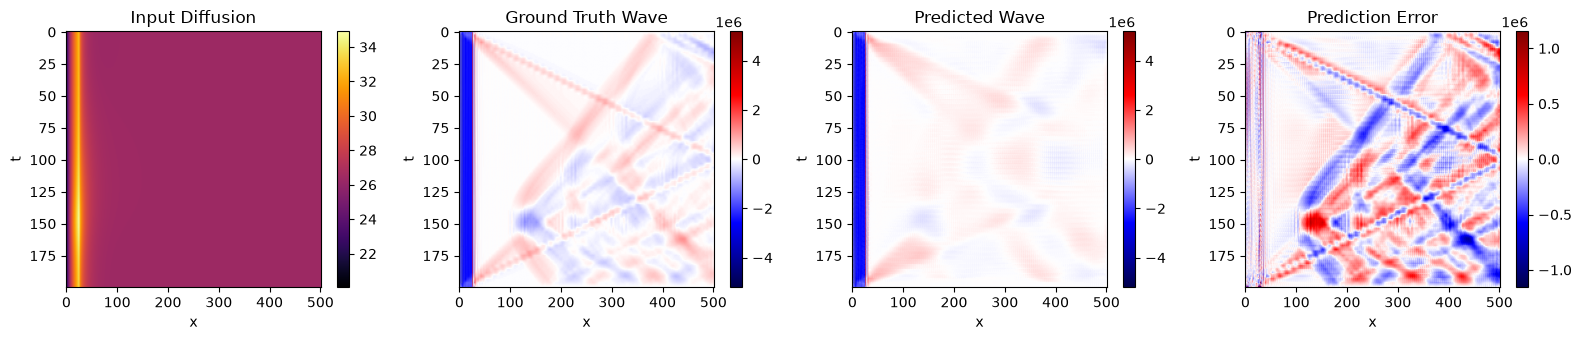

Figure saved to: galerkin_operator_results/run_20260821_143906/visualization_prediction/prediction_comparison.png


In [6]:
import os
import glob
import random
import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# Visualization prediction
# ============================================================

PREDICT_FILE = os.path.join(
    DATA_ROOT,
    "1",
    "Irregular_3_PT_0.5.mat"
)

OUT_DIR_VIS = os.path.join(
    RUN_DIR,
    "visualization_prediction"
)

os.makedirs(
    OUT_DIR_VIS,
    exist_ok=True
)


# ============================================================
# Load prediction sample
# ============================================================

def load_prediction_sample(mat_path):

    assert os.path.isfile(mat_path), (
        f"Prediction file not found: {mat_path}"
    )

    with h5py.File(
        mat_path,
        "r"
    ) as f:

        PT = np.asarray(
            f["PT"],
            dtype=np.float32
        )

        if "PA" in f:

            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )

        else:

            PA = None


    assert PT.shape == (
        NT,
        NX
    ), (
        f"Wrong PT shape: {PT.shape}"
    )


    if PA is not None:

        assert PA.shape == (
            NT,
            NX
        ), (
            f"Wrong PA shape: {PA.shape}"
        )


    return PT, PA


# ============================================================
# Load data
# ============================================================

PT_real, PA_real = load_prediction_sample(
    PREDICT_FILE
)


print(
    "PT shape:",
    PT_real.shape
)


if PA_real is not None:

    print(
        "PA ground-truth shape:",
        PA_real.shape
    )

else:

    print(
        "No PA ground truth found in this file."
    )


# ============================================================
# Normalize input
# ============================================================

PT_norm = (

    PT_real
    -
    pt_mean

) / pt_std


PT_tensor = torch.tensor(

    PT_norm,

    dtype=torch.float32

).unsqueeze(
    0

).unsqueeze(
    0

).to(
    DEVICE
)


print(
    "Network input shape:",
    PT_tensor.shape
)


# ============================================================
# Prediction
# ============================================================

galerkin_model.eval()


with torch.no_grad():

    PA_pred_norm = galerkin_model(
        PT_tensor
    )


PA_pred_norm = (

    PA_pred_norm
    .cpu()
    .squeeze(0)
    .squeeze(0)
    .numpy()
)


# ============================================================
# Denormalize predicted PA
# ============================================================

PA_pred = (

    PA_pred_norm
    *
    pa_std
    +
    pa_mean
)


print(
    "Predicted PA shape:",
    PA_pred.shape
)


# ============================================================
# Visualization
# ============================================================

if PA_real is not None:


    error = (

        PA_pred
        -
        PA_real
    )


    # --------------------------------------------------------
    # Transpose for visualization
    #
    # [501, 200] -> [200, 501]
    # --------------------------------------------------------

    PT_plot = PT_real.T

    PA_real_plot = PA_real.T

    PA_pred_plot = PA_pred.T

    error_plot = error.T


    vmax = max(

        np.max(
            np.abs(
                PA_real_plot
            )
        ),

        np.max(
            np.abs(
                PA_pred_plot
            )
        )
    )


    evmax = np.max(
        np.abs(
            error_plot
        )
    )


    fig, axes = plt.subplots(

        1,

        4,

        figsize=(
            16,
            3.5
        )
    )


    # --------------------------------------------------------
    # Input PT
    # --------------------------------------------------------

    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    # --------------------------------------------------------
    # Ground truth PA
    # --------------------------------------------------------

    im1 = axes[1].imshow(

        PA_real_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Ground Truth Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    # --------------------------------------------------------
    # Predicted PA
    # --------------------------------------------------------

    im2 = axes[2].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[2].set_title(
        "Predicted Wave"
    )

    axes[2].set_xlabel(
        "x"
    )

    axes[2].set_ylabel(
        "t"
    )


    fig.colorbar(
        im2,
        ax=axes[2]
    )


    # --------------------------------------------------------
    # Error
    # --------------------------------------------------------

    im3 = axes[3].imshow(

        error_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-evmax,

        vmax=evmax
    )


    axes[3].set_title(
        "Prediction Error"
    )

    axes[3].set_xlabel(
        "x"
    )

    axes[3].set_ylabel(
        "t"
    )


    fig.colorbar(
        im3,
        ax=axes[3]
    )


    plt.tight_layout()


else:


    PT_plot = PT_real.T

    PA_pred_plot = PA_pred.T


    fig, axes = plt.subplots(

        1,

        2,

        figsize=(
            9,
            3.5
        )
    )


    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    vmax = np.max(
        np.abs(
            PA_pred_plot
        )
    )


    im1 = axes[1].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Predicted Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plot_path = os.path.join(

    OUT_DIR_VIS,

    "prediction_comparison.png"
)


plt.savefig(

    plot_path,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "Figure saved to:",
    plot_path
)